In [1]:
import pandas as pd
import matplotlib.pyplot as mlp
df = pd.read_csv('SMHI_Data.csv')
print(df)


             Datum Tid (UTC)  Lufttemperatur
0       2010-03-01  08:00:00             0.8
1       2010-03-01  09:00:00             1.0
2       2010-03-01  10:00:00             1.0
3       2010-03-01  11:00:00             0.7
4       2010-03-01  12:00:00             1.5
...            ...       ...             ...
131712  2025-01-01  02:00:00             6.0
131713  2025-01-01  03:00:00             6.1
131714  2025-01-01  04:00:00             6.4
131715  2025-01-01  05:00:00             6.5
131716  2025-01-01  06:00:00             6.7

[131717 rows x 3 columns]


131717

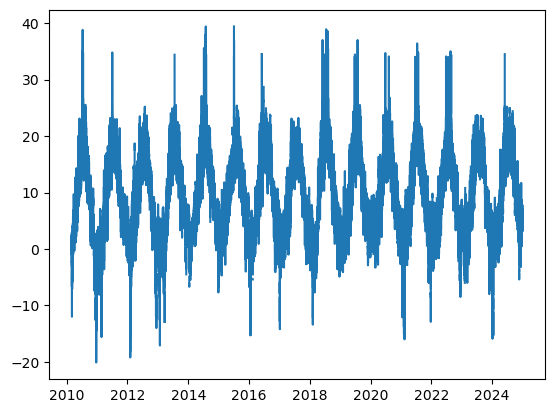

In [2]:
x = pd.to_datetime(df["Datum"].astype(str) +" " +df["Tid (UTC)"].astype(str))
y = df["Lufttemperatur"]

mlp.plot(x,y)
len(df)


# Q1: 

## Step 1
The first cleaning step is to remove all duplicates in the data. This is very important, since many duplicates can skew the data. The reason that this is should be done before other cleaning steps, is that it distorts all remaining steps and it is very simple and requires no "assumptions" of data, since we can just remove them. 

In [20]:

df_no_dupe = df.drop_duplicates()
len(df_no_dupe)

"""missing_values = df_no_dupe.isnull()
missing_list=[]
airtemp = missing_values["Lufttemperatur"]
for x in range(len(airtemp)):
    if airtemp[x]==True:
        missing_list.append(x)"""

df_no_dupe[df_no_dupe.isnull().any(axis=1)]


,Datum,Tid (UTC),Lufttemperatur
18,2010-03-02,02:00:00,NaN
46,2010-03-03,07:00:00,NaN
96,2010-03-05,10:00:00,NaN
126,2010-03-06,16:00:00,NaN
150,2010-03-07,16:00:00,NaN
...,...,...,...
131601,2024-12-27,12:00:00,NaN
131621,2024-12-28,08:00:00,NaN
131655,2024-12-29,17:00:00,NaN
131693,2024-12-31,07:00:00,NaN


# Q1

## Step 2
The next cleaning step is to standardize formats and data types. Since all data in this dataset has the same datatype across each column and a good format this step can be skipped. 

## Step 3
The next step is handling outliers. This step is done because outliers, mich like duplicates, can skew the overall data and for example make the mean or the standard deviation differ a lot from its actual value. We want as little error in the data as possible, and that is why we must handle the outliers. It is important that this step is done before handling missing values, since imputing the missing values with outliers still in the dataset, can distort the missing values and make the data invalid. We chose to split up the dataset and handle [insert months] months at a time. This is because the temperature as a whole is not normally distributed, but the temperature of each "block" of months are, or are at least very close. We then use the standard method of imputing every value that classifies as a outlier, i.e. every value that lies three standard deviations from the mean gets replaced with the mean value of the two time-wise closest valid datapoints that are not outliers. 



39.4
-20.1
0      0.8
1      1.0
2      1.0
3      0.7
4      1.5
      ... 
724    5.0
725    5.9
726    5.5
727    6.1
728    6.2
Name: Lufttemperatur, Length: 720, dtype: float64
       Lufttemperatur
count   121518.000000
mean         9.461076
std          6.975321
min        -20.100000
25%          4.100000
50%          9.100000
75%         15.300000
max         39.400000


(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  2.,  1.,  4.,  6.,
         4.,  8.,  6., 11., 16., 11., 13., 15., 23., 29., 27., 21., 18.,
        30., 28., 29., 34., 26., 29., 39., 35., 25., 32., 24., 28., 25.,
        15., 16., 24.,  7.,  3.,  2.,  4.,  0.,  0.,  0.,  1.]),
 array([-12.   , -11.566, -11.132, -10.698, -10.264,  -9.83 ,  -9.396,
         -8.962,  -8.528,  -8.094,  -7.66 ,  -7.226,  -6.792,  -6.358,
         -5.924,  -5.49 ,  -5.056,  -4.622,  -4.188,  -3.754,  -3.32 ,
         -2.886,  -2.452,  -2.018,  -1.584,  -1.15 ,  -0.716,  -0.282,
          0.152,   0.586,   1.02 ,   1.454,   1.888,   2.322,   2.756,
          3.19 ,   3.624,   4.058,   4.492,   4.926,   5.36 ,   5.794,
          6.228,   6.662,   7.096,   7.53 ,   7.964,   8.398,   8.832,
          9.266,   9.7  ]),
 <BarContainer object of 50 artists>)

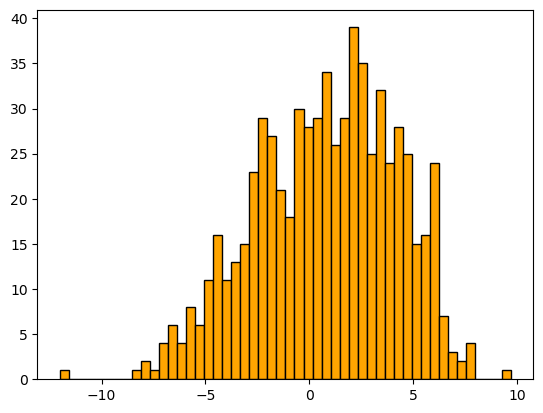

In [31]:
print(df_no_dupe["Lufttemperatur"].max())
print(df_no_dupe["Lufttemperatur"].min())
print(df_no_dupe["Lufttemperatur"][:720])

print(df_no_dupe.describe())
mlp.hist(df_no_dupe["Lufttemperatur"][:720], bins=50, color='orange', edgecolor='black')


# Q2:

This dataset contains a total of 7756 missing values, all located in the temperature column, which is [insert percentage]% of all total values. 